In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [5]:
!ls '/kaggle/input/datasets/yassmeenmostafa/dataaa/final_preprocessed_data.csv'

final_preprocessed_data.csv


In [3]:
# ============================================================
# HYBRID ViT-MLP — CUDA OPTIMIZED
# ============================================================

import os
import cv2
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import re

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.backends.cudnn as cudnn

import albumentations as A
from albumentations.pytorch import ToTensorV2

import timm
from tqdm import tqdm

# ============================================================
# CUDA OPTIMIZATION
# ============================================================
cudnn.benchmark     = True
cudnn.deterministic = False
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ============================================================
# CONFIG
# ============================================================
CSV_PATH   = '/kaggle/input/datasets/yassmeenmostafa/dataaa/final_preprocessed_data.csv'
IMG_FOLDER = "/kaggle/input/datasets/ahmedmohsen2005/xai-preprocessed-skin-lesion-17k-dataset/final_processed_images"
OUTPUT_DIR = "/kaggle/working/hybrid_vit_mlp_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 10
LR          = 1e-4
MLP_LR      = 3e-4
PATIENCE    = 3
N_SPLITS    = 5
SEED        = 42
TARGET_COL  = "class"
EMA_ALPHA   = 0.3
NUM_WORKERS = 4

torch.manual_seed(SEED)
np.random.seed(SEED)

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv(CSV_PATH)
classes      = sorted(df[TARGET_COL].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
df["label"]  = df[TARGET_COL].map(class_to_idx)
NUM_CLASSES  = len(classes)

print(f"Classes: {classes}")
print(f"Num classes: {NUM_CLASSES}")
print(f"Class distribution:\n{df['label'].value_counts()}")

# ============================================================
# IMAGE NAME FIX
# ============================================================
def normalize_name(fname):
    x    = str(fname).replace(".jpg", "")
    nums = re.findall(r'(\d{7})', x)
    if nums:
        return f"ISIC_{nums[-1]}.jpg"
    return None

df['image_fixed'] = df['image'].apply(normalize_name)
df = df[df["image_fixed"].notna()].reset_index(drop=True)
print(f"Total samples after fix: {len(df)}")

# ============================================================
# META FEATURES
# ============================================================
DROP_COLS = ["image", "isic_id", "patient_id", "year", "class", "image_fixed"]
META_COLS = [c for c in df.columns if c not in DROP_COLS + ["label"]]
META_DIM  = len(META_COLS)
print(f"Meta columns ({META_DIM}): {META_COLS}")

# ============================================================
# TRANSFORMS
# ============================================================
train_tfms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.HueSaturationValue(p=0.3),
    A.OneOf([
        A.GaussianBlur(blur_limit=3),
        A.GaussNoise(var_limit=(5, 20)),
    ], p=0.3),
    A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_tfms = A.Compose([
    A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ToTensorV2()
])

# ============================================================
# DATASET
# ============================================================
class HybridDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(IMG_FOLDER, row["image_fixed"])
        img      = cv2.imread(img_path)

        if img is None:
            return self.__getitem__((idx + 1) % len(self.df))

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(image=img)["image"]

        meta  = torch.tensor(row[META_COLS].values.astype(np.float32))
        label = torch.tensor(row["label"], dtype=torch.long)
        return img, meta, label

# ============================================================
# MODEL
# ============================================================
class HybridViTMLP(nn.Module):
    def __init__(self, meta_dim, num_classes, embed_dim=768):
        super().__init__()
        self.vit = timm.create_model(
            "vit_base_patch16_224", pretrained=True,
            num_classes=0, global_pool="token"
        )
        self.mlp = nn.Sequential(
            nn.Linear(meta_dim, 256), nn.LayerNorm(256),
            nn.GELU(), nn.Dropout(0.2),
            nn.Linear(256, 128), nn.LayerNorm(128),
            nn.GELU(), nn.Dropout(0.1),
            nn.Linear(128, 128), nn.GELU(),
        )
        self.fusion = nn.Sequential(
            nn.Linear(embed_dim + 128, 512), nn.LayerNorm(512),
            nn.GELU(), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, image, meta):
        img_feat  = self.vit(image)
        meta_feat = self.mlp(meta)
        return self.fusion(torch.cat([img_feat, meta_feat], dim=1))

# ============================================================
# SCALER للـ Mixed Precision
# ============================================================
scaler = torch.cuda.amp.GradScaler()

# ============================================================
# TRAIN LOOP — Mixed Precision + tqdm
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion, scheduler):
    model.train()
    total_loss, correct, total = 0, 0, 0
    all_labels, all_probs = [], []

    pbar = tqdm(loader, desc="  Train", leave=False,
                bar_format="{l_bar}{bar:30}{r_bar}")

    for imgs, metas, labels in pbar:
        imgs   = imgs.to(device, non_blocking=True)
        metas  = metas.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast():
            out  = model(imgs, metas)
            loss = criterion(out, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)

        all_probs.extend(torch.softmax(out, 1)[:, 1].detach().cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc":  f"{correct/total:.4f}",
            "GPU":  f"{torch.cuda.memory_reserved()/1e9:.1f}GB"
        })

    train_auc = roc_auc_score(all_labels, all_probs) \
                if len(set(all_labels)) > 1 else 0.5
    return total_loss / len(loader), correct / total, train_auc


# ============================================================
# VALID LOOP — Mixed Precision + tqdm
# ============================================================
def valid_one_epoch(model, loader, criterion=None):
    model.eval()
    preds, trues, probs_all = [], [], []
    total_loss = 0.0

    pbar = tqdm(loader, desc="  Val  ", leave=False,
                bar_format="{l_bar}{bar:30}{r_bar}")

    with torch.no_grad():
        for imgs, metas, labels in pbar:
            imgs  = imgs.to(device, non_blocking=True)
            metas = metas.to(device, non_blocking=True)

            with torch.cuda.amp.autocast():
                out = model(imgs, metas)

            if criterion is not None:
                total_loss += criterion(out, labels.to(device)).item()

            prob = torch.softmax(out, 1).cpu().numpy()
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(labels.numpy())
            probs_all.extend(prob)

            pbar.set_postfix({
                "GPU": f"{torch.cuda.memory_reserved()/1e9:.1f}GB"
            })

    trues     = np.array(trues)
    preds     = np.array(preds)
    probs_all = np.array(probs_all)

    acc      = accuracy_score(trues, preds)
    f1       = f1_score(trues, preds, average="weighted")
    auc      = roc_auc_score(trues, probs_all[:, 1]) if NUM_CLASSES == 2 \
               else roc_auc_score(trues, probs_all, multi_class="ovr", average="weighted")
    val_loss = total_loss / len(loader) if criterion is not None else None

    return acc, f1, auc, trues, preds, probs_all, val_loss

# ============================================================
# CROSS VALIDATION
# ============================================================
skf           = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_results  = []
all_histories = {}

for fold, (tr, va) in enumerate(skf.split(df, df["label"])):
    print(f"\n{'='*50}")
    print(f"  FOLD {fold+1}/{N_SPLITS}")
    print(f"{'='*50}")

    train_loader = DataLoader(
        HybridDataset(df.iloc[tr], train_tfms),
        batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True,
        persistent_workers=True)

    val_loader = DataLoader(
        HybridDataset(df.iloc[va], val_tfms),
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True,
        persistent_workers=True)

    model = HybridViTMLP(META_DIM, NUM_CLASSES).to(device)

    optimizer = torch.optim.AdamW([
        {"params": model.vit.parameters(),    "lr": LR,     "weight_decay": 1e-2},
        {"params": model.mlp.parameters(),    "lr": MLP_LR, "weight_decay": 1e-3},
        {"params": model.fusion.parameters(), "lr": MLP_LR, "weight_decay": 1e-3},
    ])

    total_steps = EPOCHS * len(train_loader)
    scheduler   = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=[LR, MLP_LR, MLP_LR],
        total_steps=total_steps, pct_start=0.1, anneal_strategy="cos")

    criterion    = nn.CrossEntropyLoss()
    best_f1      = 0
    patience_cnt = 0
    ema_auc      = None

    history = {
        "train_loss": [], "train_auc": [], "train_acc": [],
        "val_loss":   [], "val_auc":   [], "val_auc_ema": [],
        "val_f1":     [], "val_acc":   [], "threshold":   []
    }

    for epoch in range(EPOCHS):
        print(f"\n  Epoch {epoch+1:02d}/{EPOCHS}")

        torch.cuda.empty_cache()

        tr_loss, tr_acc, tr_auc = train_one_epoch(
            model, train_loader, optimizer, criterion, scheduler)

        acc, f1, auc, trues, preds, probs_all, val_loss = valid_one_epoch(
            model, val_loader, criterion)

        ema_auc = auc if ema_auc is None \
                  else EMA_ALPHA * auc + (1 - EMA_ALPHA) * ema_auc

        fpr, tpr, thresholds = roc_curve(trues, probs_all[:, 1])
        opt_thr = float(thresholds[np.argmax(tpr - fpr)])

        history["train_loss"].append(round(tr_loss, 4))
        history["train_auc"].append(round(tr_auc,   4))
        history["train_acc"].append(round(tr_acc,   4))
        history["val_loss"].append(round(val_loss,   4))
        history["val_auc"].append(round(auc,         4))
        history["val_auc_ema"].append(round(ema_auc, 4))
        history["val_f1"].append(round(f1,            4))
        history["val_acc"].append(round(acc,           4))
        history["threshold"].append(round(opt_thr,    4))

        print(f"  Train → Loss: {tr_loss:.4f} | Acc: {tr_acc:.4f} | AUC: {tr_auc:.4f}")
        print(f"  Val   → Loss: {val_loss:.4f} | Acc: {acc:.4f} | "
              f"F1: {f1:.4f} | AUC: {auc:.4f} | Thr: {opt_thr:.3f}")

        if f1 > best_f1:
            best_f1      = f1
            patience_cnt = 0
            torch.save(model.state_dict(),
                       os.path.join(OUTPUT_DIR, f"best_fold_{fold}.pth"))
            print(f"  ✅ Best saved (F1: {best_f1:.4f})")
        else:
            patience_cnt += 1
            print(f"  ⏳ No improve {patience_cnt}/{PATIENCE}")
            if patience_cnt >= PATIENCE:
                print(f"  ⏹ Early stopping!")
                break

    fold_results.append(best_f1)
    all_histories[f"fold_{fold+1}"] = history

    with open(os.path.join(OUTPUT_DIR, f"history_fold_{fold+1}.json"), "w") as fj:
        json.dump(history, fj)

    print(f"\n  📊 Fold {fold+1} Best F1: {best_f1:.4f}")

# ============================================================
# FINAL SUMMARY + SAVE
# ============================================================
print(f"\n{'='*50}")
print(f"FINAL RESULTS")
print(f"{'='*50}")
for i, f in enumerate(fold_results):
    marker = "✅ BEST" if i == np.argmax(fold_results) else ""
    print(f"  Fold {i+1}: F1 = {f:.4f}  {marker}")

print(f"\n  Mean F1 : {np.mean(fold_results):.4f}")
print(f"  Std  F1 : {np.std(fold_results):.4f}")
print(f"  Best F1 : {max(fold_results):.4f} (Fold {np.argmax(fold_results)+1})")

with open(os.path.join(OUTPUT_DIR, "all_histories.json"), "w") as fj:
    json.dump(all_histories, fj)

fold_summary = {
    "fold_f1":   fold_results,
    "mean_f1":   round(float(np.mean(fold_results)), 4),
    "std_f1":    round(float(np.std(fold_results)),  4),
    "best_fold": int(np.argmax(fold_results)) + 1
}
with open(os.path.join(OUTPUT_DIR, "fold_summary.json"), "w") as fj:
    json.dump(fold_summary, fj)

print("✅ Training done!")

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB
Classes: [np.int64(0), np.int64(1)]
Num classes: 2
Class distribution:
label
1    8530
0    8529
Name: count, dtype: int64
Total samples after fix: 17059
Meta columns (29): ['age_scaled', 'melanocytic', 'sex_Unknown', 'sex_female', 'sex_male', 'anatom_site_general_Unknown', 'anatom_site_general_anterior torso', 'anatom_site_general_head/neck', 'anatom_site_general_lateral torso', 'anatom_site_general_lower extremity', 'anatom_site_general_oral/genital', 'anatom_site_general_palms/soles', 'anatom_site_general_posterior torso', 'anatom_site_general_upper extremity', 'dermoscopic_type_Unknown', 'dermoscopic_type_contact non-polarized', 'dermoscopic_type_contact polarized', 'dermoscopic_type_non-contact polarized', 'diagnosis_confirm_type_Unknown', 'diagnosis_confirm_type_confocal microscopy with consensus dermoscopy', 'diagnosis_confirm_type_histopathology', 'diagnosis_confirm_type_serial imaging showing no change', 'diagnosis_confirm_type_


  Epoch 01/10


  Train → Loss: 0.4975 | Acc: 0.7375 | AUC: 0.8249
  Val   → Loss: 0.3714 | Acc: 0.8101 | F1: 0.8094 | AUC: 0.9083 | Thr: 0.597
  ✅ Best saved (F1: 0.8094)

  Epoch 02/10


  Train → Loss: 0.3743 | Acc: 0.8113 | AUC: 0.9033
  Val   → Loss: 0.3476 | Acc: 0.8350 | F1: 0.8349 | AUC: 0.9234 | Thr: 0.360
  ✅ Best saved (F1: 0.8349)

  Epoch 03/10


  Train → Loss: 0.3534 | Acc: 0.8285 | AUC: 0.9157
  Val   → Loss: 0.3481 | Acc: 0.8318 | F1: 0.8312 | AUC: 0.9237 | Thr: 0.476
  ⏳ No improve 1/3

  Epoch 04/10


...

  Train → Loss: 0.3168 | Acc: 0.8501 | AUC: 0.9332
  Val   → Loss: 0.3145 | Acc: 0.8511 | F1: 0.8496 | AUC: 0.9410 | Thr: 0.624
  ⏳ No improve 2/3

  Epoch 07/10


  Train → Loss: 0.3021 | Acc: 0.8579 | AUC: 0.9394
  Val   → Loss: 0.2869 | Acc: 0.8648 | F1: 0.8647 | AUC: 0.9455 | Thr: 0.525
  ✅ Best saved (F1: 0.8647)

  Epoch 08/10


  Train → Loss: 0.2896 | Acc: 0.8605 | AUC: 0.9443
  Val   → Loss: 0.2842 | Acc: 0.8648 | F1: 0.8648 | AUC: 0.9486 | Thr: 0.398
  ✅ Best saved (F1: 0.8648)

  Epoch 09/10


  Train → Loss: 0.2743 | Acc: 0.8701 | AUC: 0.9506
  Val   → Loss: 0.2843 | Acc: 0.8687 | F1: 0.8684 | AUC: 0.9493 | Thr: 0.531
  ✅ Best saved (F1: 0.8684)

  Epoch 10/10


  Train → Loss: 0.2665 | Acc: 0.8751 | AUC: 0.9534
  Val   → Loss: 0.2843 | Acc: 0.8690 | F1: 0.8687 | AUC: 0.9493 | Thr: 0.577
  ✅ Best saved (F1: 0.8687)

  📊 Fold 5 Best F1: 0.8687

FINAL RESULTS
  Fold 1: F1 = 0.8663  
  Fold 2: F1 = 0.8695  ✅ BEST
  Fold 3: F1 = 0.8624  
  Fold 4: F1 = 0.8662  
  Fold 5: F1 = 0.8687  

  Mean F1 : 0.8666
  Std  F1 : 0.0025
  Best F1 : 0.8695 (Fold 2)
✅ Training done!


In [7]:
# ============================================================
# CELL 2 — Classification Report (FIXED)
# ============================================================


best_fold_idx = int(np.argmax(fold_results))


model = HybridViTMLP(META_DIM, NUM_CLASSES).to(device)
model_path = os.path.join(OUTPUT_DIR, f"best_fold_{best_fold_idx}.pth")

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path))
    print(f"✅ Loaded weights from: {model_path}")
else:
 
    fallback_path = os.path.join(OUTPUT_DIR, f"best_hybrid_fold_{best_fold_idx}.pth")
    if os.path.exists(fallback_path):
        model.load_state_dict(torch.load(fallback_path))
        print(f"✅ Loaded weights from fallback: {fallback_path}")
    else:
        raise FileNotFoundError(f"❌ Could not find the model file at {model_path}")


_, va = list(skf.split(df, df["label"]))[best_fold_idx]
final_loader = DataLoader(
    HybridDataset(df.iloc[va], val_tfms),
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


acc, f1, auc, trues, preds, probs_all, _ = valid_one_epoch(model, final_loader)


target_names = [str(c) for c in classes]

print(f"\n{'='*45}")
print(f"BEST FOLD {best_fold_idx+1} — Classification Report")
print(f"{'='*45}")
print(classification_report(trues, preds, target_names=target_names))
print(f"Accuracy : {acc:.4f}")
print(f"F1       : {f1:.4f}")
print(f"AUC-ROC  : {auc:.4f}")


cm = confusion_matrix(trues, preds)
final_metrics = {
    "best_fold": best_fold_idx + 1,
    "accuracy":  round(float(acc), 4),
    "f1":        round(float(f1),  4),
    "auc":       round(float(auc), 4),
    "confusion_matrix": {
        "TN": int(cm[0,0]), "FP": int(cm[0,1]),
        "FN": int(cm[1,0]), "TP": int(cm[1,1])
    }
}

with open(os.path.join(OUTPUT_DIR, "final_metrics.json"), "w") as fj:
    json.dump(final_metrics, fj, indent=2)

report_dict = classification_report(trues, preds, target_names=target_names, output_dict=True)
with open(os.path.join(OUTPUT_DIR, "classification_report.json"), "w") as fj:
    json.dump(report_dict, fj, indent=2)

print(f"\n✅ Saved: final_metrics.json + classification_report.json")

✅ Loaded weights from: /kaggle/working/hybrid_vit_mlp_outputs/best_fold_1.pth



BEST FOLD 2 — Classification Report
              precision    recall  f1-score   support

           0       0.89      0.85      0.87      1706
           1       0.85      0.89      0.87      1706

    accuracy                           0.87      3412
   macro avg       0.87      0.87      0.87      3412
weighted avg       0.87      0.87      0.87      3412

Accuracy : 0.8696
F1       : 0.8695
AUC-ROC  : 0.9493

✅ Saved: final_metrics.json + classification_report.json


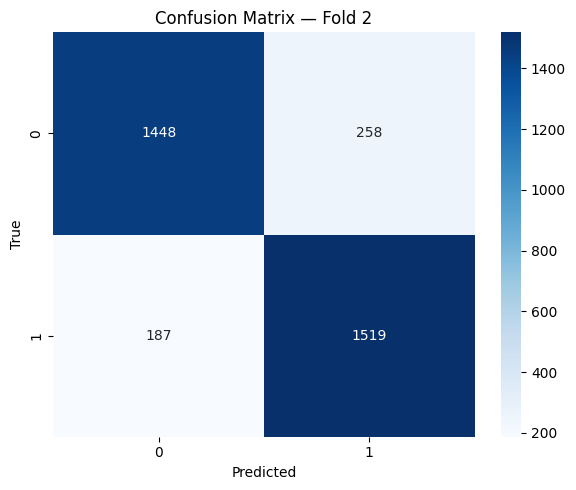

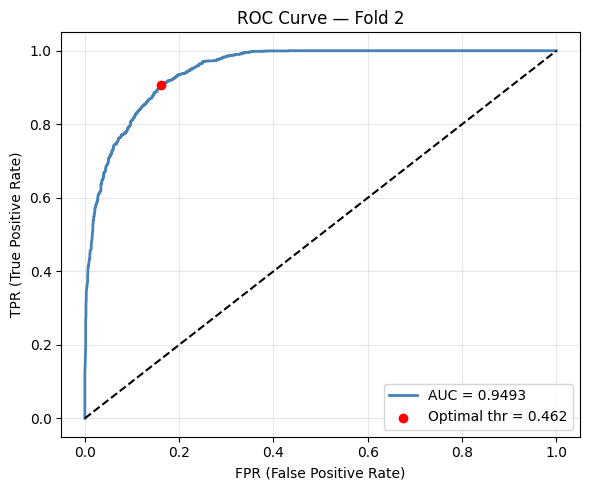

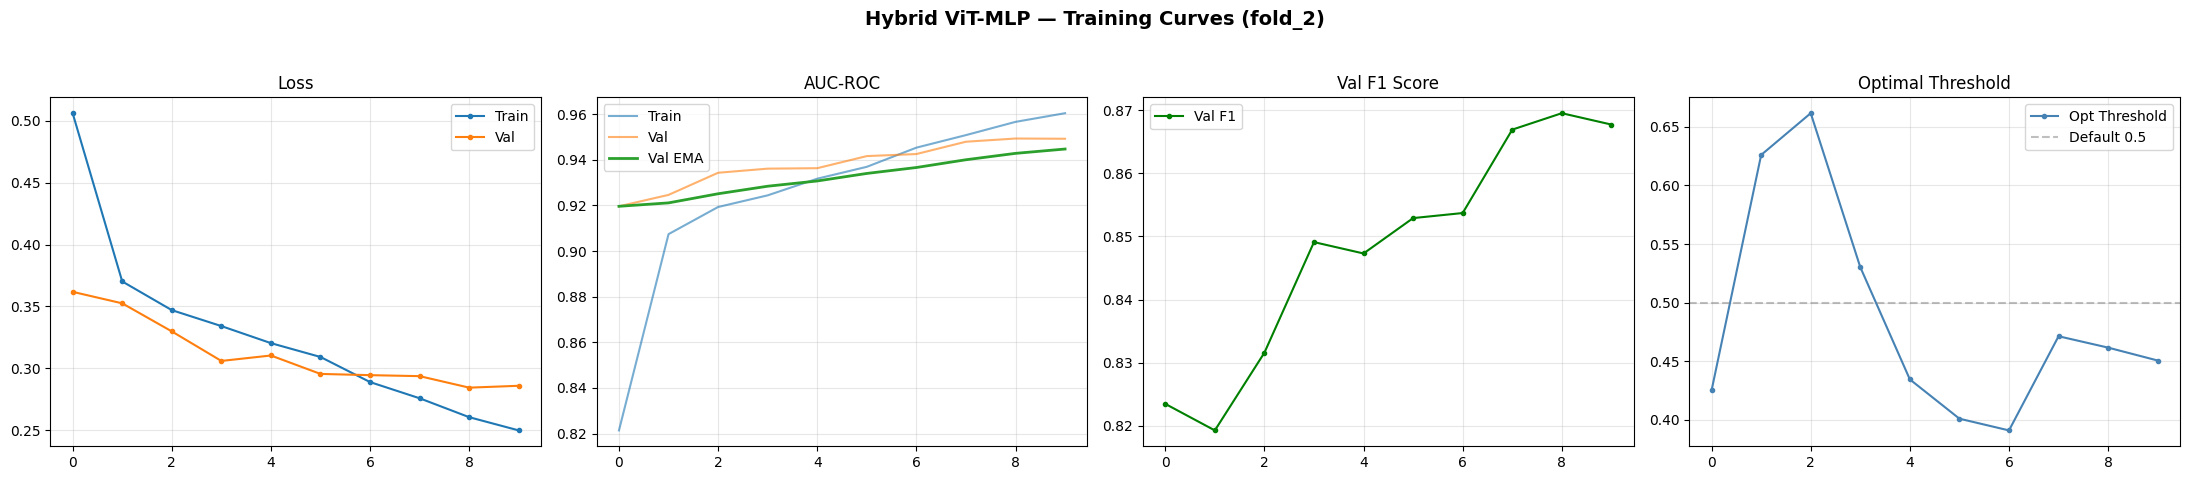

In [9]:
# ============================================================
# CELL 3 — Visualizations 
# ============================================================
import seaborn as sns
from sklearn.metrics import roc_curve


current_fold_num = best_fold_idx + 1 

probs = probs_all[:, 1] if probs_all.ndim > 1 else probs_all

# 1 — Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[str(c) for c in classes],
            yticklabels=[str(c) for c in classes], ax=ax)
ax.set_ylabel("True")
ax.set_xlabel("Predicted")
ax.set_title(f"Confusion Matrix — Fold {current_fold_num}")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"confusion_matrix_fold{current_fold_num}.png"), dpi=150)
plt.show()

# 2 — ROC Curve
fpr, tpr, thresholds = roc_curve(trues, probs)

thresholds = np.nan_to_num(thresholds)
youden_idx = np.argmax(tpr - fpr)
opt_thr    = thresholds[youden_idx]

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, lw=2, color="steelblue", label=f"AUC = {auc:.4f}")
ax.scatter(fpr[youden_idx], tpr[youden_idx], color="red", zorder=5,
           label=f"Optimal thr = {opt_thr:.3f}")
ax.plot([0, 1], [0, 1], "k--")
ax.set_xlabel("FPR (False Positive Rate)")
ax.set_ylabel("TPR (True Positive Rate)")
ax.set_title(f"ROC Curve — Fold {current_fold_num}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"roc_curve_fold{current_fold_num}.png"), dpi=150)
plt.show()

# 3 — Training Curves
history_key = f"fold_{current_fold_num}"
if history_key in all_histories:
    history = all_histories[history_key]
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    # Loss
    axes[0].plot(history["train_loss"], label="Train", marker="o", ms=3)
    axes[0].plot(history["val_loss"],   label="Val",   marker="o", ms=3)
    axes[0].set_title("Loss")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # AUC
    axes[1].plot(history["train_auc"],   label="Train",   alpha=0.6)
    axes[1].plot(history["val_auc"],     label="Val",     alpha=0.6)
    if "val_auc_ema" in history:
        axes[1].plot(history["val_auc_ema"], label="Val EMA", lw=2)
    axes[1].set_title("AUC-ROC")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    # Val F1
    axes[2].plot(history["val_f1"], label="Val F1", color="green", marker="o", ms=3)
    axes[2].set_title("Val F1 Score")
    axes[2].legend(); axes[2].grid(True, alpha=0.3)

    # Threshold
    axes[3].plot(history["threshold"], label="Opt Threshold", color="steelblue", marker="o", ms=3)
    axes[3].axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Default 0.5")
    axes[3].set_title("Optimal Threshold")
    axes[3].legend(); axes[3].grid(True, alpha=0.3)

    plt.suptitle(f"Hybrid ViT-MLP — Training Curves ({history_key})",
                 fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(os.path.join(OUTPUT_DIR, f"training_curves_{history_key}.png"), dpi=150)
    plt.show()
else:
    print(f"⚠️ History for {history_key} not found in all_histories.")

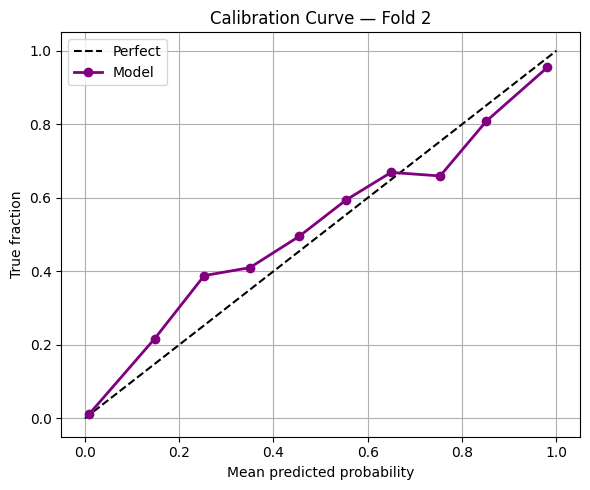


✅ All visualizations saved to: /kaggle/working/hybrid_vit_mlp_outputs


In [10]:
# 4 — Calibration Curve
import numpy as np

probs_arr = np.array(probs)
trues_arr = np.array(trues)

n_bins = 10
bins   = np.linspace(0, 1, n_bins + 1)
centers, fracs = [], []

for i in range(n_bins):
    mask = (probs_arr >= bins[i]) & (probs_arr < bins[i+1])
    if mask.sum() > 0:
        centers.append(probs_arr[mask].mean())
        fracs.append(trues_arr[mask].mean())

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], "k--", label="Perfect")
ax.plot(centers, fracs, marker="o", lw=2, color="purple", label="Model")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("True fraction")
ax.set_title(f"Calibration Curve — Fold {best_fold+1}")
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"calibration_fold{best_fold+1}.png"), dpi=150)
plt.show()
print(f"\n✅ All visualizations saved to: {OUTPUT_DIR}")


  SHAP INTERPRETABILITY - OPTIMIZED VERSION
Using Best Fold: 2
✅ Model weights loaded successfully.
Starting SHAP computation for 20 samples...


  0%|          | 0/20 [00:00<?, ?it/s]

✅ SHAP computation finished!


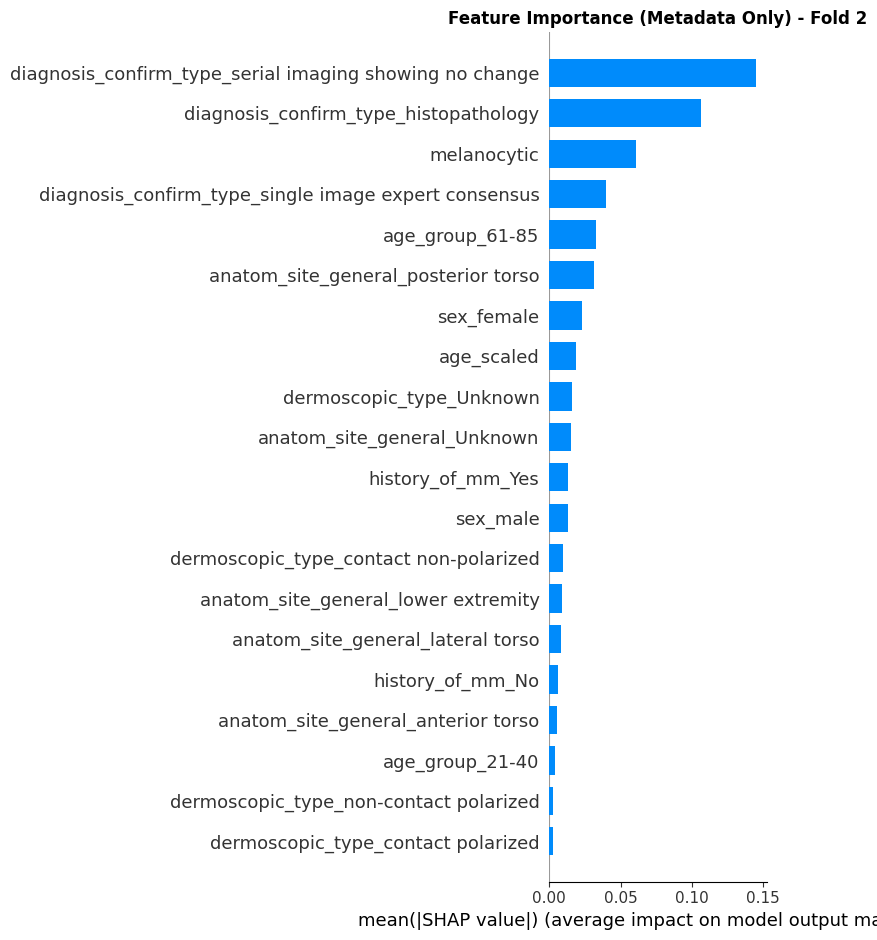

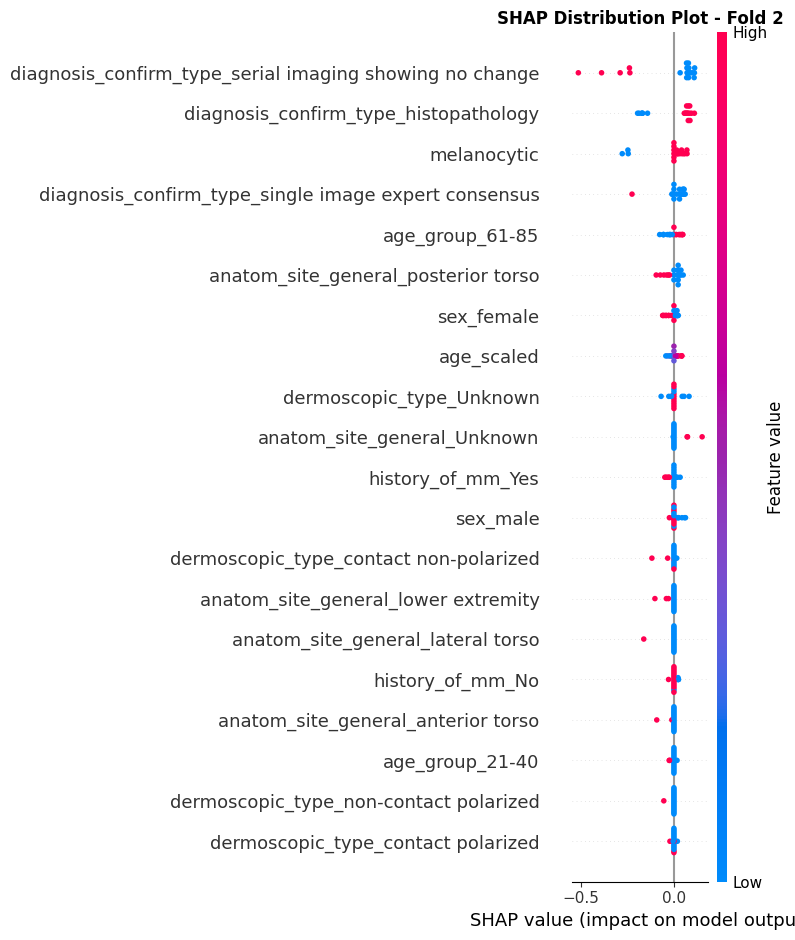

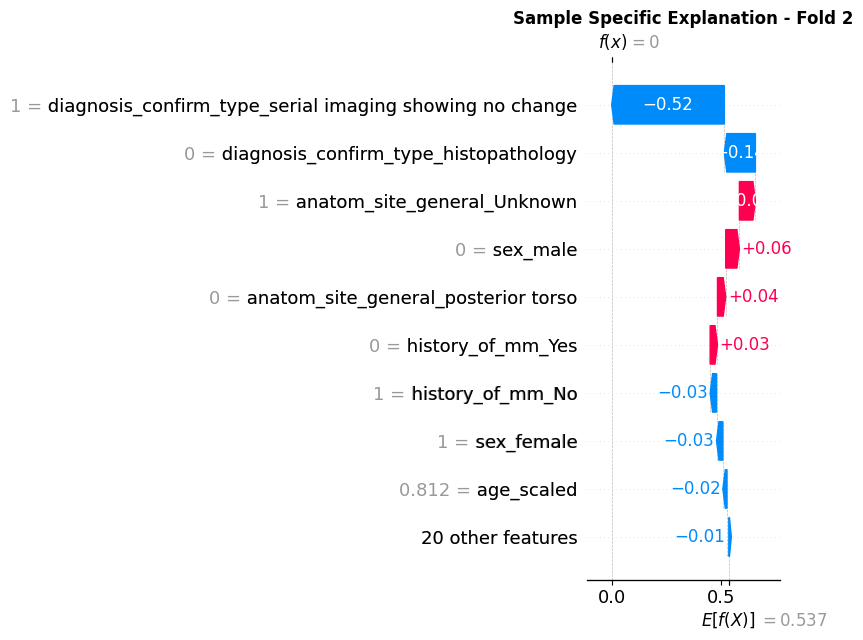


  TOP 5 METADATA FEATURES
1. diagnosis_confirm_type_serial imaging showing no change | SHAP: 0.1451
2. diagnosis_confirm_type_histopathology | SHAP: 0.1063
3. melanocytic                    | SHAP: 0.0605
4. diagnosis_confirm_type_single image expert consensus | SHAP: 0.0398
5. age_group_61-85                | SHAP: 0.0326

🚀 All done! Outputs saved in: /kaggle/working/hybrid_vit_mlp_outputs


In [11]:
import shap
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ============================================================
# 1. LOAD BEST MODEL & PREPARE DEVICE
# ============================================================
print("\n" + "="*50)
print("  SHAP INTERPRETABILITY - OPTIMIZED VERSION")
print("="*50)


best_fold_idx = int(np.argmax(fold_results))
print(f"Using Best Fold: {best_fold_idx + 1}")


model_shap = HybridViTMLP(META_DIM, NUM_CLASSES).to(device)
model_path = os.path.join(OUTPUT_DIR, f"best_fold_{best_fold_idx}.pth")

if os.path.exists(model_path):
    model_shap.load_state_dict(torch.load(model_path, map_location=device))
    print(f"✅ Model weights loaded successfully.")
else:
    print(f"⚠️ Error: Model file not found at {model_path}!")

model_shap.eval()

# ============================================================
# 2. DATA PREPARATION (Small Subset for Speed)
# ============================================================

_, va_idx = list(skf.split(df, df["label"]))[best_fold_idx]
val_subset = df.iloc[va_idx].reset_index(drop=True)


N_SHAP_TOTAL = 50 
sample_df = val_subset.sample(n=min(len(val_subset), N_SHAP_TOTAL), random_state=SEED).reset_index(drop=True)


background_np = sample_df[META_COLS].values.astype(np.float32)
background_summary = shap.kmeans(background_np, 10) 

test_meta_np = sample_df[META_COLS].sample(n=min(20, len(sample_df)), random_state=SEED).values.astype(np.float32)

# ============================================================
# 3. HIGH-SPEED PREDICTOR FUNCTION (The Optimization)
# ============================================================
def predict_proba_optimized(meta_numpy: np.ndarray) -> np.ndarray:

    model_shap.eval()
    dataset_size = meta_numpy.shape[0]
    all_probs = []
    
  
    meta_t = torch.tensor(meta_numpy, dtype=torch.float32).to(device)
    
 
    batch_size = 128 
    
    with torch.no_grad():
        for i in range(0, dataset_size, batch_size):
            batch_meta = meta_t[i : i + batch_size]
            curr_batch_len = batch_meta.shape[0]
            
         
            dummy_img = torch.zeros(curr_batch_len, 3, IMG_SIZE, IMG_SIZE).to(device)
            
          
            with torch.cuda.amp.autocast():
                logits = model_shap(dummy_img, batch_meta)
                probs = torch.softmax(logits, dim=1).cpu().numpy()
            
            all_probs.append(probs)
            
    return np.concatenate(all_probs, axis=0)

# ============================================================
# 4. RUN SHAP EXPLAINER
# ============================================================
print(f"Starting SHAP computation for {len(test_meta_np)} samples...")
explainer = shap.KernelExplainer(predict_proba_optimized, background_summary)


shap_values = explainer.shap_values(test_meta_np, nsamples=150)
print("✅ SHAP computation finished!")


if isinstance(shap_values, list):
    shap_mel = np.array(shap_values[1]) # Class 1 (Melanoma)
else:
    sv_arr = np.array(shap_values)
    shap_mel = sv_arr[:, :, 1] if sv_arr.ndim == 3 else sv_arr

ev = explainer.expected_value
base_val = float(np.array(ev).flat[1]) if isinstance(ev, (list, np.ndarray)) else float(ev)

# ============================================================
# 5. VISUALIZATION
# ============================================================
# 1. Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_mel, test_meta_np, feature_names=META_COLS, plot_type="bar", show=False)
plt.title(f"Feature Importance (Metadata Only) - Fold {best_fold_idx+1}", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_optimized_bar.png"), dpi=150)
plt.show()

# 2. Beeswarm Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_mel, test_meta_np, feature_names=META_COLS, show=False)
plt.title(f"SHAP Distribution Plot - Fold {best_fold_idx+1}", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_optimized_beeswarm.png"), dpi=150)
plt.show()

# 3. Waterfall for One Sample
explanation = shap.Explanation(
    values=shap_mel[0],
    base_values=base_val,
    data=test_meta_np[0],
    feature_names=META_COLS
)
plt.figure(figsize=(10, 5))
try:
    shap.plots.waterfall(explanation, show=False)
except:
    shap.waterfall_plot(explanation, show=False)
plt.title(f"Sample Specific Explanation - Fold {best_fold_idx+1}", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_optimized_waterfall.png"), dpi=150)
plt.show()

# ============================================================
# 6. FINAL LOGS
# ============================================================
mean_abs_shap = np.abs(shap_mel).mean(axis=0)
sorted_idx = np.argsort(mean_abs_shap)[::-1]

print("\n" + "="*30)
print("  TOP 5 METADATA FEATURES")
print("="*30)
for rank, i in enumerate(sorted_idx[:5], 1):
    print(f"{rank}. {META_COLS[i]:30s} | SHAP: {mean_abs_shap[i]:.4f}")

print(f"\n🚀 All done! Outputs saved in: {OUTPUT_DIR}")


  SHAP INTERPRETABILITY - OPTIMIZED VERSION (100 SAMPLES)
Using Best Fold: 2
✅ Model weights loaded successfully.
✅ Prepared 100 samples for SHAP computation.
Starting SHAP computation for 100 samples... (Please wait)


  0%|          | 0/100 [00:00<?, ?it/s]

✅ SHAP computation finished!


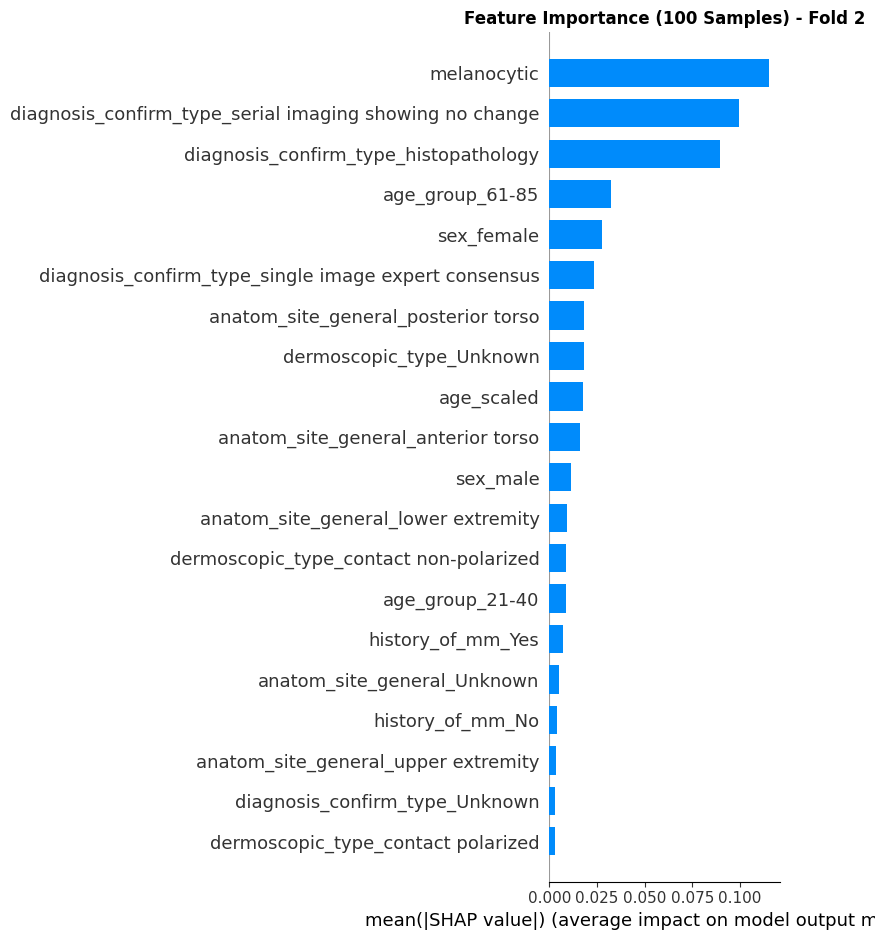

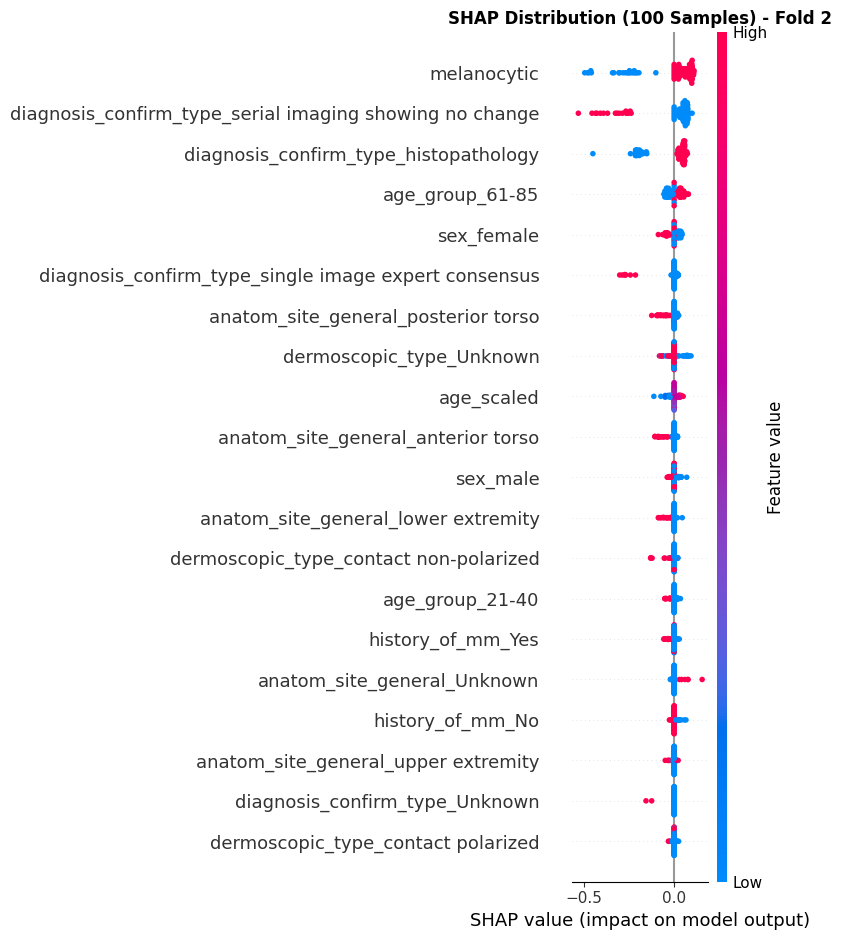

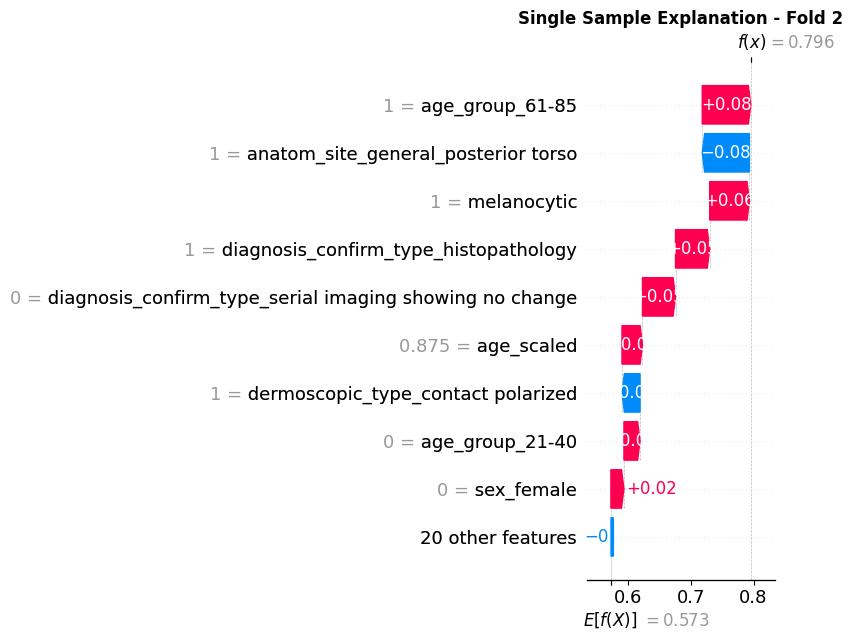


  TOP METADATA INFLUENCERS
1. melanocytic                    | SHAP: 0.1152
2. diagnosis_confirm_type_serial imaging showing no change | SHAP: 0.0995
3. diagnosis_confirm_type_histopathology | SHAP: 0.0895
4. age_group_61-85                | SHAP: 0.0322
5. sex_female                     | SHAP: 0.0278
6. diagnosis_confirm_type_single image expert consensus | SHAP: 0.0233
7. anatom_site_general_posterior torso | SHAP: 0.0183
8. dermoscopic_type_Unknown       | SHAP: 0.0180
9. age_scaled                     | SHAP: 0.0176
10. anatom_site_general_anterior torso | SHAP: 0.0163

🚀 SHAP Analysis Complete! Files saved in: /kaggle/working/hybrid_vit_mlp_outputs


In [12]:
import shap
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ============================================================
# 1. LOAD BEST MODEL & PREPARE DEVICE
# ============================================================
print("\n" + "="*50)
print("  SHAP INTERPRETABILITY - OPTIMIZED VERSION (100 SAMPLES)")
print("="*50)


best_fold_idx = int(np.argmax(fold_results))
print(f"Using Best Fold: {best_fold_idx + 1}")

model_shap = HybridViTMLP(META_DIM, NUM_CLASSES).to(device)
model_path = os.path.join(OUTPUT_DIR, f"best_fold_{best_fold_idx}.pth")

if os.path.exists(model_path):
    model_shap.load_state_dict(torch.load(model_path, map_location=device))
    print(f"✅ Model weights loaded successfully.")
else:
    print(f"⚠️ Error: Model file not found at {model_path}!")

model_shap.eval()

# ============================================================
# 2. DATA PREPARATION (100 Samples)
# ============================================================

_, va_idx = list(skf.split(df, df["label"]))[best_fold_idx]
val_subset = df.iloc[va_idx].reset_index(drop=True)


N_SHAP_TOTAL = 100 
sample_df = val_subset.sample(n=min(len(val_subset), N_SHAP_TOTAL), random_state=SEED).reset_index(drop=True)


background_np = sample_df[META_COLS].values.astype(np.float32)


background_summary = shap.kmeans(background_np, 15) 


test_meta_np = sample_df[META_COLS].values.astype(np.float32)

print(f"✅ Prepared {len(test_meta_np)} samples for SHAP computation.")

# ============================================================
# 3. HIGH-SPEED PREDICTOR FUNCTION
# ============================================================
def predict_proba_optimized(meta_numpy: np.ndarray) -> np.ndarray:

    model_shap.eval()
    dataset_size = meta_numpy.shape[0]
    all_probs = []
    

    meta_t = torch.tensor(meta_numpy, dtype=torch.float32).to(device)
    

    batch_size = 128 
    
    with torch.no_grad():
        for i in range(0, dataset_size, batch_size):
            batch_meta = meta_t[i : i + batch_size]
            curr_batch_len = batch_meta.shape[0]
            
          
            dummy_img = torch.zeros(curr_batch_len, 3, IMG_SIZE, IMG_SIZE).to(device)
            
            with torch.cuda.amp.autocast():
                logits = model_shap(dummy_img, batch_meta)
                probs = torch.softmax(logits, dim=1).cpu().numpy()
            
            all_probs.append(probs)
            
    return np.concatenate(all_probs, axis=0)

# ============================================================
# 4. RUN SHAP EXPLAINER
# ============================================================
print(f"Starting SHAP computation for {len(test_meta_np)} samples... (Please wait)")
explainer = shap.KernelExplainer(predict_proba_optimized, background_summary)


shap_values = explainer.shap_values(test_meta_np, nsamples=150)
print("✅ SHAP computation finished!")


if isinstance(shap_values, list):
    shap_mel = np.array(shap_values[1]) 
else:
    sv_arr = np.array(shap_values)
    shap_mel = sv_arr[:, :, 1] if sv_arr.ndim == 3 else sv_arr

ev = explainer.expected_value
base_val = float(np.array(ev).flat[1]) if isinstance(ev, (list, np.ndarray)) else float(ev)

# ============================================================
# 5. VISUALIZATION
# ============================================================
# 1. Bar Plot (Global Importance)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_mel, test_meta_np, feature_names=META_COLS, plot_type="bar", show=False)
plt.title(f"Feature Importance (100 Samples) - Fold {best_fold_idx+1}", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_bar_100.png"), dpi=150)
plt.show()

# 2. Beeswarm Plot (Impact Distribution)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_mel, test_meta_np, feature_names=META_COLS, show=False)
plt.title(f"SHAP Distribution (100 Samples) - Fold {best_fold_idx+1}", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_beeswarm_100.png"), dpi=150)
plt.show()

# 3. Waterfall Plot (First Sample)
explanation = shap.Explanation(
    values=shap_mel[0].astype(np.float64),
    base_values=float(base_val),
    data=test_meta_np[0].astype(np.float64),
    feature_names=META_COLS
)
plt.figure(figsize=(10, 5))
try:
    shap.plots.waterfall(explanation, show=False)
except:
    shap.waterfall_plot(explanation, show=False)
plt.title(f"Single Sample Explanation - Fold {best_fold_idx+1}", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_waterfall_100.png"), dpi=150)
plt.show()

# ============================================================
# 6. FINAL SUMMARY LOGS
# ============================================================
mean_abs_shap = np.abs(shap_mel).mean(axis=0)
sorted_idx = np.argsort(mean_abs_shap)[::-1]

print("\n" + "="*30)
print("  TOP METADATA INFLUENCERS")
print("="*30)
for rank, i in enumerate(sorted_idx[:10], 1):
    print(f"{rank}. {META_COLS[i]:30s} | SHAP: {mean_abs_shap[i]:.4f}")

print(f"\n🚀 SHAP Analysis Complete! Files saved in: {OUTPUT_DIR}")

🚀 Generating Comparison Grid for 3 samples...


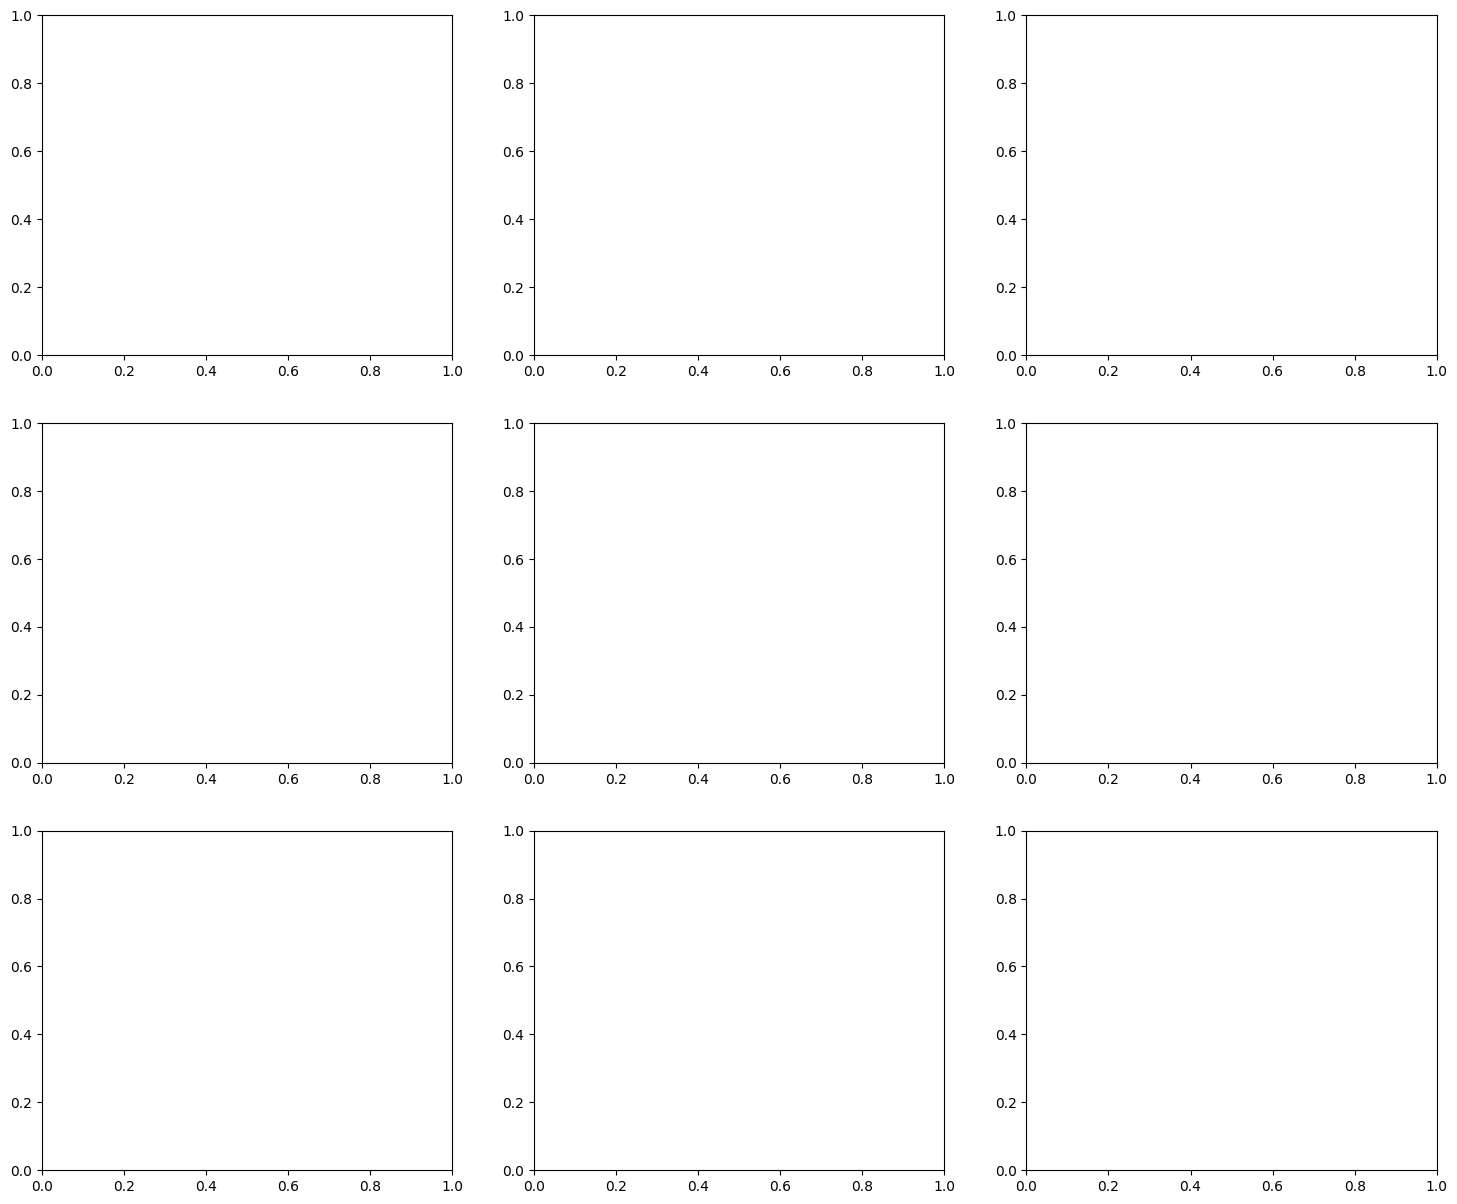

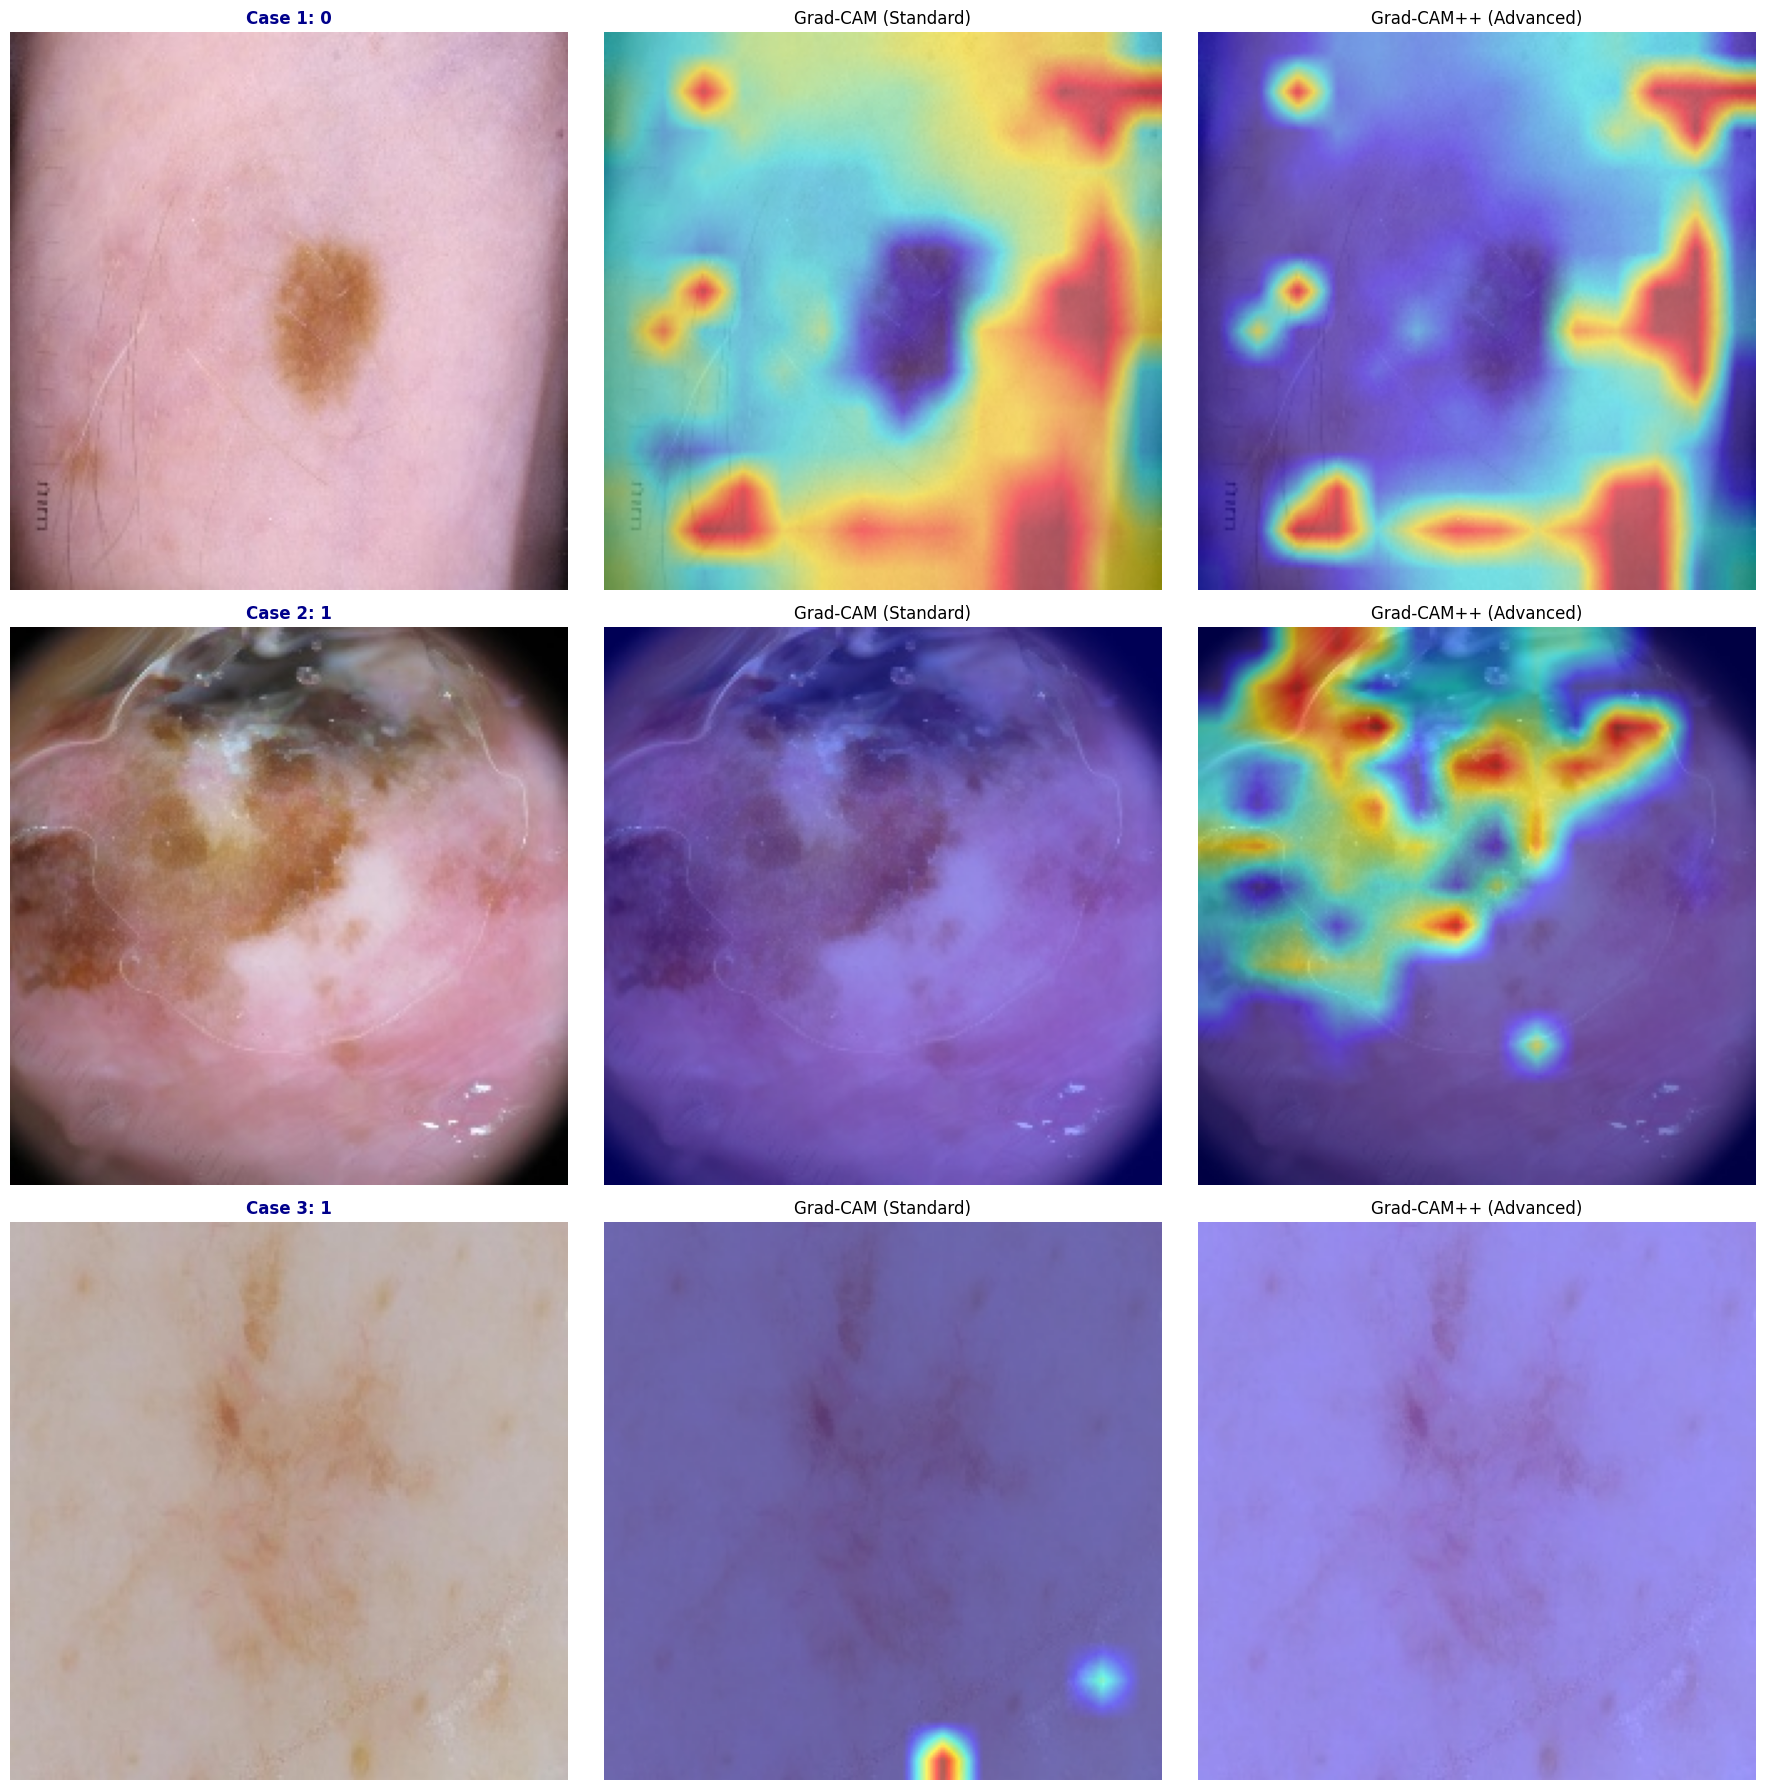

✅ All Done! Visualizations saved in: /kaggle/working/hybrid_vit_mlp_outputs


In [15]:
# ============================================================
# CELL 6 — FINAL: COMPARISON GRID (ORIGINAL vs GRAD-CAM vs GRAD-CAM++)
# ============================================================


try:
    import pytorch_grad_cam
except ImportError:
    print("Installing pytorch-grad-cam...")
    !pip install grad-cam -q

import cv2
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import os
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# ------------------------------------------------------------
# 2.(Reshape & Wrapper)
# ------------------------------------------------------------

def reshape_transform(tensor, height=14, width=14):


    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

class HybridWrapper(nn.Module):

    def __init__(self, model, meta):
        super().__init__()
        self.model = model
        self.meta = meta
    def forward(self, x):
        return self.model(x, self.meta)


model_shap.eval()

target_layers = [model_shap.vit.blocks[-1].norm1] 



n_samples = 3 
indices = np.random.choice(len(val_subset), n_samples, replace=False)

fig, axes = plt.subplots(n_samples, 3, figsize=(18, 6 * n_samples))

print(f"🚀 Generating Comparison Grid for {n_samples} samples...")

for i, idx in enumerate(indices):
    row = val_subset.iloc[idx]
    
  
    img_path = os.path.join(IMG_FOLDER, row["image_fixed"])
    img_bgr = cv2.imread(img_path)
    if img_bgr is None: continue
    
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    
  
    img_tensor = val_tfms(image=img_resized)["image"].unsqueeze(0).to(device)
    meta_tensor = torch.tensor(row[META_COLS].values.astype(np.float32)).unsqueeze(0).to(device)
    
   
    wrapped_model = HybridWrapper(model_shap, meta_tensor)
    targets = [ClassifierOutputTarget(row["label"])]
    

    cam_args = {
        "model": wrapped_model,
        "target_layers": target_layers,
        "reshape_transform": reshape_transform
    }

 
    with GradCAM(**cam_args) as cam:
        mask = cam(input_tensor=img_tensor, targets=targets)[0, :]
        res_std = show_cam_on_image(img_resized.astype(np.float32)/255, mask, use_rgb=True)
        

    with GradCAMPlusPlus(**cam_args) as cam_pp:
        mask_pp = cam_pp(input_tensor=img_tensor, targets=targets)[0, :]
        res_plus = show_cam_on_image(img_resized.astype(np.float32)/255, mask_pp, use_rgb=True)

 
    axes[i, 0].imshow(img_resized)
    axes[i, 0].set_title(f"Case {i+1}: {row[TARGET_COL]}", fontweight="bold", color="darkblue")
    axes[i, 0].axis('off')
    
  
    axes[i, 1].imshow(res_std)
    axes[i, 1].set_title(f"Grad-CAM (Standard)")
    axes[i, 1].axis('off')
    

    axes[i, 2].imshow(res_plus)
    axes[i, 2].set_title(f"Grad-CAM++ (Advanced)")
    axes[i, 2].axis('off')

plt.tight_layout()

plt.savefig(os.path.join(OUTPUT_DIR, "final_interpretation_comparison.png"), dpi=200)
plt.show()

print(f"✅ All Done! Visualizations saved in: {OUTPUT_DIR}")

🚀 Generating Comparison Grid for 10 samples... This may take a moment.


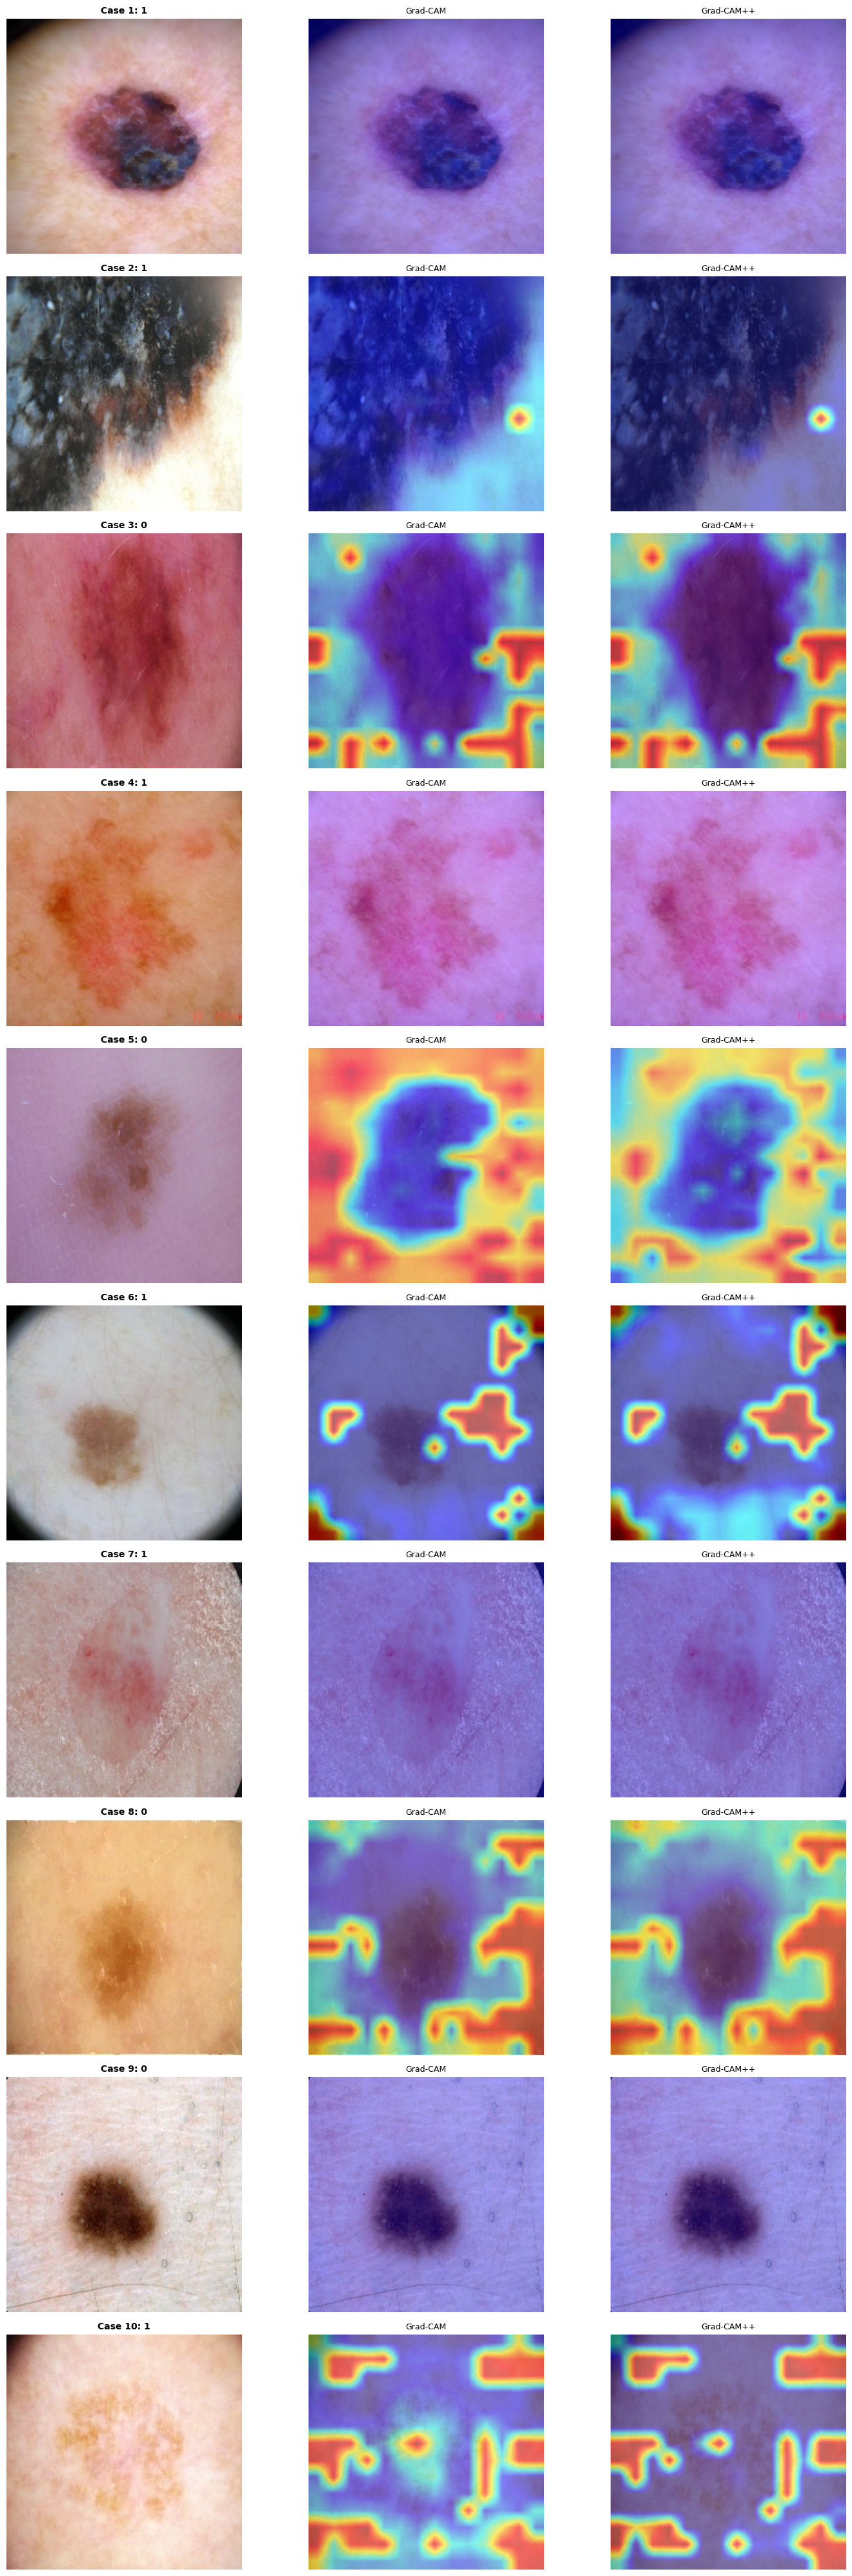

✅ Finished! 10 samples grid saved in: /kaggle/working/hybrid_vit_mlp_outputs


In [16]:
# ============================================================
# CELL 6 — FINAL: COMPARISON GRID (10 SAMPLES)
# ============================================================


try:
    import pytorch_grad_cam
except ImportError:
    !pip install grad-cam -q

import cv2
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import os
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# ------------------------------------------------------------
# 2.(Reshape & Wrapper)
# ------------------------------------------------------------

def reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

class HybridWrapper(nn.Module):
    def __init__(self, model, meta):
        super().__init__()
        self.model = model
        self.meta = meta
    def forward(self, x):
        return self.model(x, self.meta)

model_shap.eval()
target_layers = [model_shap.vit.blocks[-1].norm1] 



n_samples = 10  
indices = np.random.choice(len(val_subset), n_samples, replace=False)


fig, axes = plt.subplots(n_samples, 3, figsize=(15, 4 * n_samples))

print(f"🚀 Generating Comparison Grid for {n_samples} samples... This may take a moment.")

for i, idx in enumerate(indices):
    row = val_subset.iloc[idx]
    
 
    img_path = os.path.join(IMG_FOLDER, row["image_fixed"])
    img_bgr = cv2.imread(img_path)
    if img_bgr is None: continue
    
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    
    # Tensors
    img_tensor = val_tfms(image=img_resized)["image"].unsqueeze(0).to(device)
    meta_tensor = torch.tensor(row[META_COLS].values.astype(np.float32)).unsqueeze(0).to(device)
    
    wrapped_model = HybridWrapper(model_shap, meta_tensor)
    targets = [ClassifierOutputTarget(row["label"])]
    
    cam_args = {
        "model": wrapped_model,
        "target_layers": target_layers,
        "reshape_transform": reshape_transform
    }

    # Grad-CAM
    with GradCAM(**cam_args) as cam:
        mask = cam(input_tensor=img_tensor, targets=targets)[0, :]
        res_std = show_cam_on_image(img_resized.astype(np.float32)/255, mask, use_rgb=True)
        
    # Grad-CAM++
    with GradCAMPlusPlus(**cam_args) as cam_pp:
        mask_pp = cam_pp(input_tensor=img_tensor, targets=targets)[0, :]
        res_plus = show_cam_on_image(img_resized.astype(np.float32)/255, mask_pp, use_rgb=True)

  
    axes[i, 0].imshow(img_resized)
    axes[i, 0].set_title(f"Case {i+1}: {row[TARGET_COL]}", fontsize=10, fontweight="bold")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(res_std)
    axes[i, 1].set_title("Grad-CAM", fontsize=9)
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(res_plus)
    axes[i, 2].set_title("Grad-CAM++", fontsize=9)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "final_comparison_10_samples.png"), dpi=150)
plt.show()

print(f"✅ Finished! 10 samples grid saved in: {OUTPUT_DIR}")